In [ ]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from scipy.io import savemat
import twixtools
import matplotlib.pyplot as plt
import recon_plot_helpers
import save_data_helpers
from ismrm_figs import mvf_utils

In [2]:
import numpy as np
import os

def load_data(filepath, shape):
    """
    Load data saved by save_data function.
    """
    dtype = np.float32
    
    # Read binary data
    with open(filepath, 'rb') as f:
        data_flat = np.fromfile(f, dtype=dtype)
    
    # Determine the shape after axis movement (if it happened during save)
    if len(shape) > 3:
        # Stored shape has gate dimension at the end
        stored_shape = shape[1:] + (shape[0],)
    else:
        stored_shape = shape
    
    # Reshape using Fortran order (same as used during save)
    data = np.reshape(data_flat, stored_shape, order='F')
    
    # Move gate axis back to first position if needed
    if len(shape) > 3:
        data = np.moveaxis(data, -1, 0)
    
    return data

    # help function to create interpolation operators:
def motion_vec_field_2_op_list(mvf,m):
    
        xp = np

        # ensure border of MVF is all zeros:
        if True:
            mvf[:,0,...]=0
            mvf[:,-1,...]=0
            mvf[:,:,0,...]=0
            mvf[:,:,-1,...]=0
            mvf[:,:,:,0,...]=0
            mvf[:,:,:,-1,...]=0

        # asserting mvf is 4d, with time/gate dimension in first dim:
        op_list=[]
        in_x = xp.arange(0,m[0],1)
        in_y = xp.arange(0,m[1],1)
        in_z = xp.arange(0,m[2],1)
        x,y,z = xp.meshgrid(in_x,in_y,in_z,indexing='ij')
        base_grid = xp.stack((x,y,z),axis=-1)
        for gate in range(mvf.shape[0]):
            op_list.append(sp.linop.Interpolate(tuple(m),base_grid+mvf[gate,...]))

        return op_list

def load_mvfs(filepath, num_gates, mvf_shape):
    dtype = np.float32
    
    # Read binary data
    with open(filepath, 'rb') as f:
        mvf_flat = np.fromfile(f, dtype=dtype)
    
    mvf = np.reshape(mvf_flat, (*mvf_shape, 3, num_gates), order='F')
    mvf = np.moveaxis(mvf, -1, 0)
    return mvf

(5, 58, 512, 512)


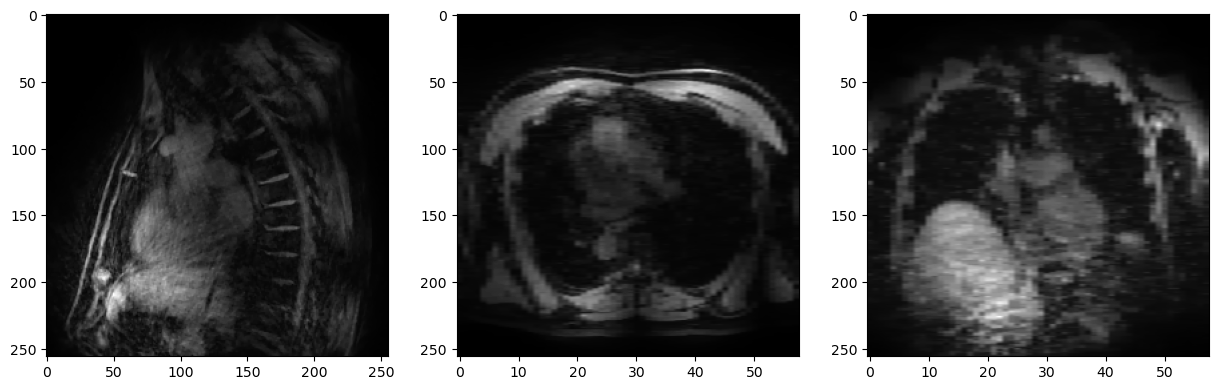

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [3]:
base_dir_recons = f"/data/lilianae/ADMM_results/400sp_George/recon_output/high_beta_tv_z_rho_0.01_beta_0.005_lam_0.007/indep_recons_000_abs.v"
shape = (5, 58, 512, 512)
indep_recons = load_data(base_dir_recons, shape=shape)
print(indep_recons.shape)
oshape = (58, 256, 256)
indep_recons_cropped = recon_plot_helpers.crop_xy_dimension(indep_recons[3], oshape=oshape)
recon_plot_helpers.plot_recons_all_axes(np.abs(indep_recons_cropped))

### Save Recons as Nifti

In [ ]:
# import nibabel as nib
# import numpy as np

# # Assuming you have your cropped data
# # indep_recons shape: (5, 58, 512, 512)
# # After cropping: 5 images of shape (58, 256, 256)

# def save_as_nifti(data, output_path, voxel_size=(5.0, 1.172, 1.172)):
#     """
#     Save 3D numpy array as NIfTI file with specified voxel spacing.
    
#     Parameters:
#     -----------
#     data : numpy.ndarray
#         3D array of shape (z, y, x) = (58, 256, 256)
#     output_path : str
#         Path where to save the .nii or .nii.gz file
#     voxel_size : tuple
#         Voxel dimensions in mm as (z, y, x)
#     """
#     # Ensure data is in the correct format
#     data = np.array(data, dtype=np.float32)
#     print(f'data.shape = {data.shape}')
    
#     # Create affine matrix with voxel spacing
#     # The affine matrix encodes voxel size and orientation
#     affine = np.diag([voxel_size[2], voxel_size[1], voxel_size[0], 1.0])

#     # Create NIfTI image
#     nifti_img = nib.Nifti1Image(data.T, affine)  # Transpose for correct orientation
    
#     # Save to file
#     nib.save(nifti_img, output_path)
#     print(f"Saved: {output_path}")

# # Save all 5 gates
# output_dir = "/home/lilianae/projects/naf_clean/nifti_files"
# os.makedirs(output_dir, exist_ok=True)

# oshape = (58, 256, 256)

# for gate in range(5):
#     # Crop each gate
#     cropped_data = recon_plot_helpers.crop_xy_dimension(indep_recons[gate], oshape=oshape)
    
#     # Save as NIfTI
#     output_path = os.path.join(output_dir, f"gate_{gate:02d}.nii.gz")
#     save_as_nifti(cropped_data, output_path, voxel_size=(5.0, 1.172, 1.172))

# # print(f"\nAll 5 gates saved to {output_dir}")
# print("You can now open these files in ITK-SNAP")

data.shape = (58, 256, 256)
Saved: /home/lilianae/projects/naf_clean/nifti_files/gate_00.nii.gz
data.shape = (58, 256, 256)
Saved: /home/lilianae/projects/naf_clean/nifti_files/gate_01.nii.gz
data.shape = (58, 256, 256)
Saved: /home/lilianae/projects/naf_clean/nifti_files/gate_02.nii.gz
data.shape = (58, 256, 256)
Saved: /home/lilianae/projects/naf_clean/nifti_files/gate_03.nii.gz
data.shape = (58, 256, 256)
Saved: /home/lilianae/projects/naf_clean/nifti_files/gate_04.nii.gz
You can now open these files in ITK-SNAP
